In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import silhouette_score

from sklearn.cluster import AgglomerativeClustering # 병합 계층 클러스터링 알고리즘을 사용하기 위해 import 한다.

계층 클러스터링(hierarchial clustering) 알고리즘은 데이터 간 계층을 기반으로 데이터 간 병합 또는 분할을 통해서 해당 데이터 포인트가 속할 그룹을 결정한다. 계층 클러스터링은 크게 병합 계층 클러스터링(agglomerative hierarchial clustering)과 분할 계층 클러스터링(division hierarchial clustering)으로 나눌 수 있다.

병합 계층 클러스터링은 개별 데이터 포인트를 하나의 클러스터로 설정하고 시작하는 방법으로 데이터 포인트가 100개가 있다면 100개의 클러스터가 존재한다고 설정하는 것이다. 그리고 각 클러스터를 비교해서 클러스터간 유사도가 높을 경우 두 개의 클러스터를 하나의 클러스터로 합치는 방법이다. 처음에는 다수의 클러스터로 시작하지만 결국에는 데이터셋 전체가 하나의 클러스터로 묶이는 방법이다.

분할 계층 클러스터링은 병합 계층 클러스터링과는 반대로 전체 데이터셋을 하나의 클러스터로 설정하고 시작하는 방법으로 데이터 포인트가 100개가 있다면 이 데이터셋 전체를 1개의 클러스터도 설정하고 시작하는 것이다. 그리고 클러스터 내부에서 가장 멀리 떨어진 데이터 포인트를 다른 클러스터로 분리하는 방법이다. 처음에는 하나의 클러스터로 시작하지만 결국에는 클러스터가 데이터 포인트 개수만큼 분리되는 방법이다.

병합 계층 클러스터링 알고리즘을 활용해서 클러스터링 한다.

데이터 불러오기

In [2]:
x_train, y_train = datasets.make_blobs(n_samples=100, n_features=2, centers=6, random_state=10)
print(x_train.shape, y_train.shape)

(100, 2) (100,)


병합 계층 클러스터링 모델 생성 후 데이터 학습

In [9]:
# n_clusters 속성에 클러스터 개수, linkage 속성에 거리를 측정하는 방법을 지정해서 병합 계층 클러스터 모델을 만든다.
# 모든 데이터 포인트가 각각 하나의 클러스터를 구성하는 것을 보고싶으면 n_clusters 속성값을 None으로 지정하면 되는데 반드시 distance_threshold 속성값을 0으로
# 지정해야 에러가 발생되지 않는다.
# linkage 속성으로 지정할 수 있는 거리 측정 방법은 기본값이 'ward'이고 'complete', 'average', 'single'를 지정할 수 있다.
# ward: 병합되는 클러스터들의 분산을 최소화 한다. 최소 분산 방법
# complete: 모든 데이터 조합에 대한 거리를 측정해서 가장 큰 값을 구한다. 최장 거리 방법
# average: 모든 데이터 조합에 대한 거리를 측정해서 평균 값을 구한다. 평균 거리 방법
# single: 모든 데이터 조합에 대한 거리를 측정해서 가장 작은 값을 구한다. 최소 거리 방법
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='complete')
# 병합 계층 클러스터링은 비지도 학습이므로 학습 데이터만 넘겨서 모델을 학습시킨다.
model.fit(x_train)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

In [11]:
# 클러스터링 결과를 확인한다.
# labels_ 속성으로 클러스터링 결과를 확인할 수 있다.
print(model.labels_)
# fit_predict() 메소드에 피쳐 데이터를 넘겨서 예측하면 클러스터링 결과와 같은 결과가 나온다.
print(model.fit_predict(x_train))

[88 57 75 93 80 92 69 59 76 77 72 99 91 63 82 71 37 66 55 94 81 60 67 35
 87 61 46 83 73 98 54 84 41 62 65 56 43 68 78 64 97 27 49 58 33 52 48 53
 28 38 50 74 79 90 29 95 85 13 96 70 45 34 22 16 40 32 47 86 36 18 30 23
 31 42 26 17 51 39 89 24 25 44 19 21 10 12  8 15 20 11 14  7  9  5  6  3
  4  2  1  0]
[88 57 75 93 80 92 69 59 76 77 72 99 91 63 82 71 37 66 55 94 81 60 67 35
 87 61 46 83 73 98 54 84 41 62 65 56 43 68 78 64 97 27 49 58 33 52 48 53
 28 38 50 74 79 90 29 95 85 13 96 70 45 34 22 16 40 32 47 86 36 18 30 23
 31 42 26 17 51 39 89 24 25 44 19 21 10 12  8 15 20 11 14  7  9  5  6  3
  4  2  1  0]


In [12]:
model = AgglomerativeClustering(n_clusters=6, linkage='complete')
model.fit(x_train)
print(model.labels_)
print(model.fit_predict(x_train))

[3 5 2 2 0 2 1 1 0 3 4 2 0 3 0 2 5 1 0 1 1 2 3 2 2 2 3 4 0 1 1 3 3 0 3 3 5
 4 3 4 1 1 4 1 0 4 4 3 0 5 0 5 0 3 4 0 0 3 5 1 2 5 5 1 3 2 5 5 5 0 4 4 2 1
 0 2 3 3 4 1 3 2 2 0 0 4 1 5 4 1 4 1 4 5 4 2 5 5 5 4]
[3 5 2 2 0 2 1 1 0 3 4 2 0 3 0 2 5 1 0 1 1 2 3 2 2 2 3 4 0 1 1 3 3 0 3 3 5
 4 3 4 1 1 4 1 0 4 4 3 0 5 0 5 0 3 4 0 0 3 5 1 2 5 5 1 3 2 5 5 5 0 4 4 2 1
 0 2 3 3 4 1 3 2 2 0 0 4 1 5 4 1 4 1 4 5 4 2 5 5 5 4]


병합 계층 클러스터링 알고리즘으로 클러스터링 된 데이터 시각화

In [13]:
# 클러스터링된 데이터를 시각화 하기 위해서 데이터프레임으로 만든다.
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.labels_
df

,x,y,label,cluster
0,-6.086784,4.729827,3,3
1,3.801750,4.278268,1,5
2,-7.330583,-8.494063,4,2
3,-6.107069,-7.818906,4,2
4,5.525562,-8.186965,0,0
...,...,...,...,...
95,-6.950884,-9.024594,4,2
96,2.591843,4.446782,1,5
97,2.992321,5.436981,1,5
98,2.310466,4.854172,1,5


In [14]:
# make_blobs() 메소드가 만들어준 레이블과 병합 계층 클러스터링 알고리즘으로 클러스터링된 레이블의 종류 확인
print(set(df.label), set(df.cluster))

{0, 1, 2, 3, 4, 5} {0, 1, 2, 3, 4, 5}


make_blobs() 메소드가 만들어준 레이블별 시각화

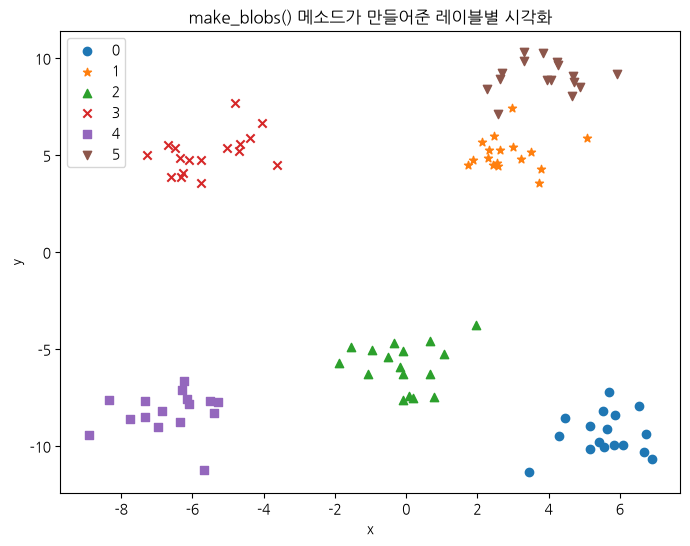

In [15]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('make_blobs() 메소드가 만들어준 레이블별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

병합 계층 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화

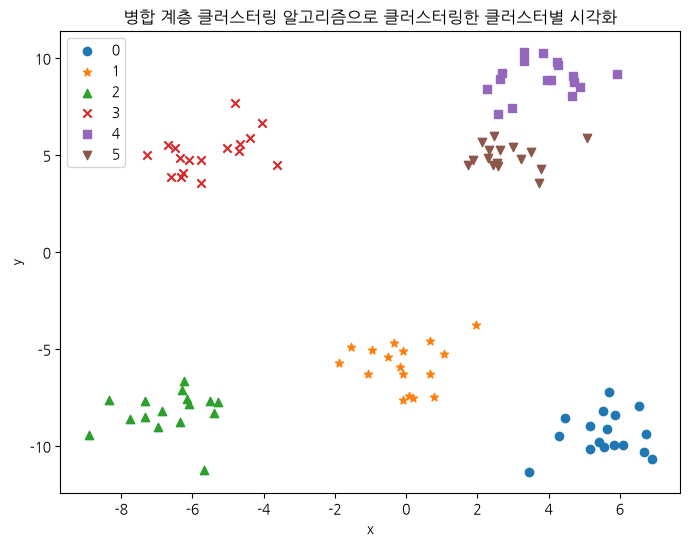

In [16]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('병합 계층 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

학습된 모델을 평가한다.

In [17]:
# silhouette_score() 함수에 피쳐(x_train)와 군집화 결과로 얻은 클러스터(model.labels_)를 넘겨서 실루엣 스코에를 계산한다.
sil_score = silhouette_score(x_train, model.labels_)
print(sil_score)

0.700081972794829


덴드로그램(dendrogeam) 시각화

계층적 클러스터링 결과를 트리 구조로 나타내는 그림을 덴드로그램이라 한다.

In [19]:
x_train, y_train = datasets.make_blobs(n_samples=20, n_features=2, centers=6, random_state=10)
print(x_train.shape, y_train.shape)
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='complete')
model.fit(x_train)
print(model.labels_)

(20, 2) (20,)
[16 17 15 19 18 13  7 10 14 12 11  8  3  5  9  6  2  4  1  0]


In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

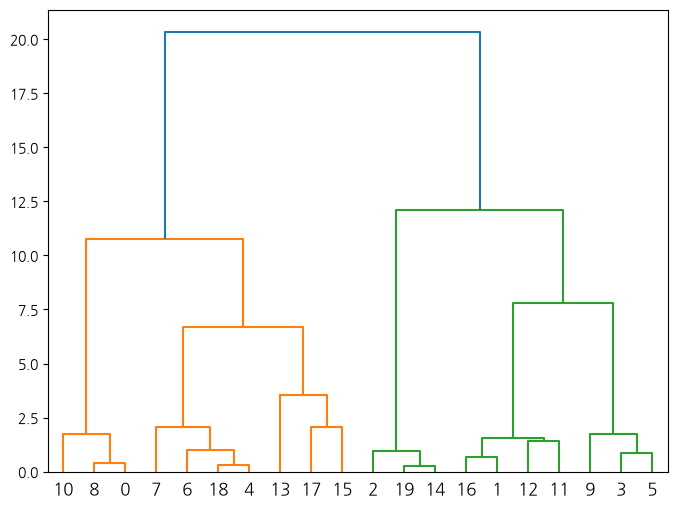

In [25]:
plt.figure(figsize=[8, 6])
linked = linkage(x_train, 'complete')
dendrogram(linked, orientation='top', labels=model.labels_)
plt.show()